In [4]:
# 그럼 첫번째 레슨 : 라이브러리 불러오기

#필요한 딥러닝 관련 라이브러리를 불러옵니다.

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

In [37]:
# 🗂️ Step 2: 데이터 불러오기

#CIFAR-10 데이터셋을 불러오고, 학습용/테스트용으로 분리합니다.

(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()


## 과제1. 데이터의 구조를 살펴보세요. 사이즈는?

In [38]:
# 여기에서 확인해 보세요.
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

batch_size = 32
train_loader = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
train_loader = train_loader.shuffle(buffer_size=10000).batch(batch_size)

for X_train, y_train in train_loader:
    print(f"X_train: {X_train.shape}, dtype: {X_train.dtype}")
    print(f"y_train: {y_train.shape}, dtype: {y_train.dtype}")
    break

X_train: (32, 32, 32, 3), dtype: <dtype: 'float32'>
y_train: (32, 1), dtype: <dtype: 'uint8'>


In [39]:
# 🏷️ Step 3: 클래스 이름 정의

#CIFAR-10의 라벨은 숫자로 되어 있으므로, 사람이 이해할 수 있도록 이름을 부여합니다.
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

## 과제2. 아래 코드의 빈칸을 채워 CNN 모델을 완성해보세요. 
#### layer나 패딩 혹은 drop out, batch normalization을 추가해 가며 모델의 정확도 변화를 보는 것도 좋습니다.

In [40]:
# 🧱 Step 4: CNN 모델 구성
# Convolution → MaxPooling → Flatten → Dense 구조로 CNN을 설계합니다.
# 아래의 빈칸 (___)을 채워 모델을 완성해보세요.

model = models.Sequential()

# 첫 번째 합성곱 레이어
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))  # TODO: 커널 개수 설정

# 첫 번째 풀링 레이어
model.add(layers.MaxPooling2D((2, 2)))  # TODO: 풀링 크기 설정

# 두 번째 합성곱 레이어
model.add(layers.Conv2D(64, (3, 3), activation='relu'))  # TODO: 커널 크기 설정

# 두 번째 풀링 레이어
model.add(layers.MaxPooling2D((2, 2)))

# 세 번째 합성곱 레이어
model.add(layers.Conv2D(64, (3, 3), activation='relu'))  # TODO: 커널 개수 설정

# Flatten + Fully Connected Layer
model.add(layers.Flatten())
model.add(layers.Dense(64))  # TODO: 은닉층 유닛 수 설정
model.add(layers.Dense(10))  # 출력층: CIFAR-10은 클래스가 10개

## 자신이 채운 코드를 기반으로 각 레이어별 Feature Map 크기를 계산해 보세요. 
(padding은 디폴트로 없습니다.)

Answer:
##### input     : (32, 32, 3)
##### Conv2D_1  : (32, 32, 3)   ->  (30, 30, 32)
##### pooling_1 : (30, 30, 32)  ->  (15, 15, 32)
##### Conv2D_2  : (15, 15, 32)  ->  (13, 13, 64)
##### pooling_2 : (13, 13, 64)  ->  (6, 6, 64)
##### Conv2D_3  : (6, 6, 64)    ->  (4, 4, 64)
##### flatten   : (4, 4, 64)    ->  (1024)
##### fc layer  : (1024)        ->  (64)
##### output    : (64)          ->  (10)

In [41]:
# ⚙️ Step 5: 모델 컴파일

#모델을 학습할 수 있도록 컴파일합니다. 손실 함수, 최적화 방법, 평가지표를 설정합니다.

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - accuracy: 0.3849 - loss: 1.6733 - val_accuracy: 0.5414 - val_loss: 1.3097
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.5962 - loss: 1.1458 - val_accuracy: 0.6329 - val_loss: 1.0439
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6509 - loss: 0.9937 - val_accuracy: 0.6657 - val_loss: 0.9532
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.6869 - loss: 0.8929 - val_accuracy: 0.6637 - val_loss: 0.9540
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.7189 - loss: 0.8054 - val_accuracy: 0.6849 - val_loss: 0.9016
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.7350 - loss: 0.7603 - val_accuracy: 0.6975 - val_loss: 0.8686
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.7525 - loss: 0.7056 - val_accuracy: 0.7040 - val_loss: 0.8707
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.7630 -

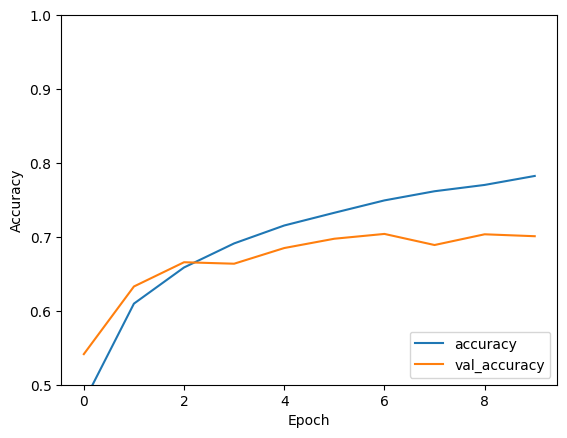

In [42]:
# 🔥 Step 6: 모델 학습 및 성능 평가

history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))
#모델 성능 평가
plt.plot(history.history['accuracy'],label='accuracy')
plt.plot(history.history['val_accuracy'],label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images,
                                     test_labels,
                                     verbose=2)


In [43]:
print('Test Accuracy is',test_acc)

Test Accuracy is 0.7009000182151794


## 과제3. 직접사용해 보기. 이미지를 로드하고 cifar-10의 사이즈로 리사이즈

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


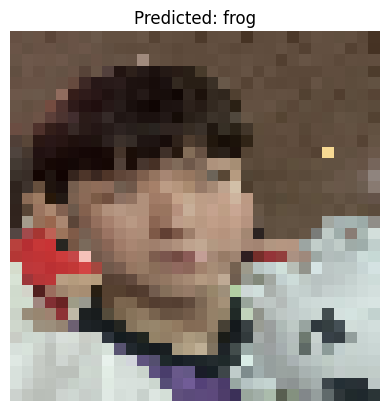

In [47]:
import numpy as np
from tensorflow.keras.preprocessing import image

# 새 이미지를 로드하고 모델 예측 수행
def predict_new_image(image_path, model, class_names):
    # 이미지 로드 및 전처리
    img = image.load_img(image_path, target_size=(32, 32))  # CIFAR-10 크기로 리사이즈 빈칸채우기
    img_array = image.img_to_array(img)  # 이미지를 배열로 변환
    img_array = np.expand_dims(img_array, axis=0)  # 배치를 위해 차원 추가
    img_array = img_array / 255.0  # 정규화 

    # 예측 수행
    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions)  # 가장 높은 확률의 클래스 인덱스
    class_name = class_names[predicted_class]  # 클래스 이름

    # 결과 출력
    plt.imshow(img)
    plt.title(f"Predicted: {class_name}")
    plt.axis('off')
    plt.show()

# 사용 예시
image_path = r"C:\Users\midas\OneDrive\바탕 화면\4-2\BOAZ\BASE\my_CNN.jpg" # 예측할 이미지의 경로 절대경로를 입력하면 됩니다. 뭔가 자신의 얼굴사진을 넣어보면 재미있는일이...
predict_new_image(image_path, model, class_names)


frog..?

## 왜 255.0으로 나누었을까요? 이미지 전처리에 대한 지식이니 조사해보세요.

Answer:
##### Image data의 값은 R, G, B 3개의 채널이 [0, 255]의 값을 부여받기 때문에 255로 나누어 [0, 1] 범위 안으로 변환하는 normalization 해야하기 때문이다.

## 과제4. CNN의 inductive bias에 대해서 조사를 해보고 생각해 봅시다.
### CNN은 왜 이미지 처리에 좋을까요? 이미지 말고도 CNN을 잘 쓸 수 있는데는 어디일까요?

Answer:
##### Inductive bias, 귀납적 편향은 학습하지 않은 새로운 데이터에도 일반화한다는 뜻이다.
##### 이 특징으로 인해 CNN으로 이미지 처리에서 edge, color 등의 변화를 알아볼 수 있고, [눈, 코, 입, ...] 다양한 부위를 인식하여 구분한다.
##### CNN은 weight sharing 덕분에 고해상도 이미지 처리도 가능하며, pooling layer로 인해 robust하게 feature extract한다.
##### CNN은 weight sharing 중인 kernel을 이용하기에 국소적인 패턴을 찾는데 능하다.
##### 그로 인해 이미지 처리 외에 time-series, DNA&RNA 염기서열과 같이 순간적인 변화와 반복 패턴(= edge, color gradient)을 찾아야 할 때 유용하다.